In [1]:
import os, sys, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torchvision
from PIL import Image

# Версии (Задание 1)
print("python     :", sys.version.split()[0])
print("torch      :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("cuda       :", torch.cuda.is_available())

# Seed (Задание 1)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print("seed set")

python     : 3.12.4
torch      : 2.11.0+cpu
torchvision: 0.26.0+cpu
cuda       : False
seed set


In [2]:
ROOT = Path("../data/raw")
CSV_PATH = ROOT / "selected_by_name_iimk_subset_public.csv"
IMG_DIR  = ROOT / "dataset"

df = pd.read_csv(CSV_PATH)
print(f"CSV rows   : {len(df)}")
print(f"CSV columns: {df.columns.tolist()}")

img_files = sorted(IMG_DIR.glob("*.jpg"))
print(f"Image files: {len(img_files)}")

CSV rows   : 1389
CSV columns: ['Unnamed: 0', 'code', 'name', 'description', 'material', 'size', 'fragm', 'cultlayer', 'execorg', 'survyear']
Image files: 1388


In [3]:
import unicodedata

def normalize(s):
    return unicodedata.normalize("NFC", str(s))

files_by_code = {}
for f in img_files:
    code = normalize(f.stem.replace("_orig", ""))
    files_by_code.setdefault(code, []).append(f)

df["image_path"] = df["code"].map(lambda c: files_by_code.get(normalize(c), []))
df["n_images"]   = df["image_path"].apply(len)

print(f"rows с >=1 картинкой : {(df['n_images'] >= 1).sum()} / {len(df)}")
print(f"rows без картинок    : {(df['n_images'] == 0).sum()}")
print(f"всего файлов сматчено: {df['n_images'].sum()}")
print()
print("Распределение числа картинок на запись:")
print(df["n_images"].value_counts().sort_index())

rows с >=1 картинкой : 1389 / 1389
rows без картинок    : 0
всего файлов сматчено: 1389

Распределение числа картинок на запись:
n_images
1    1389
Name: count, dtype: int64


In [8]:
rows = []
for _, r in df.iterrows():
    for img_path in r["image_path"]:
        rows.append({
            "code": r["code"],
            "name": r["name"],
            "description": r["description"],
            "material": r["material"],
            "size": r["size"],
            "fragm": r["fragm"],
            "cultlayer": r["cultlayer"],
            "image_file": str(img_path.relative_to(ROOT)),
            "group_key": normalize(str(r["code"])),
        })

df_long = pd.DataFrame(rows)
print(f"Пар (строка ↔ файл): {len(df_long)}")
print(f"Уникальных group_key: {df_long['group_key'].nunique()}")
print()
print("Колонки:", df_long.columns.tolist())
df_long.head()

Пар (строка ↔ файл): 1389
Уникальных group_key: 1388

Колонки: ['code', 'name', 'description', 'material', 'size', 'fragm', 'cultlayer', 'image_file', 'group_key']


,code,name,description,material,size,fragm,cultlayer,image_file,group_key
0,М102-2012-1-0494,Изразец,Изразца красноглиняного с белой поливой и коба...,Керамика,"7+ х 3,5+ х 1,1+ см",Фрагмент,Пестрая мешаная супесь,dataset\М102-2012-1-0494_orig.jpg,М102-2012-1-0494
1,М102-2012-1-0496,Изразец,Изразца красноглиняного плоского с белой полив...,Керамика,"9,9+ х 6,4+ х 1,3+ см",Фрагмент,Пестрая мешаная супесь,dataset\М102-2012-1-0496_orig.jpg,М102-2012-1-0496
2,М102-2012-1-0529,Изразец,Изразца-перемычки красноглиняного с белой поли...,Керамика,"4,5+ х 4,3 х 4,2+ см",Фрагмент,Пестрая мешаная супесь,dataset\М102-2012-1-0529_orig.jpg,М102-2012-1-0529
3,М102-2012-1-0585,Тарелка,Сосуда (тарелки ?) фаянсового с белой поливой ...,Фаянс,D? см,Фрагмент,Дерн со щепой,dataset\М102-2012-1-0585_orig.jpg,М102-2012-1-0585
4,М102-2012-1-0603,Изразец,Изразца (перемычки?) красноглиняного с белой п...,Керамика,"3,8+ х 2,8 х 5,1+ см",Фрагмент,Дерн со щепой,dataset\М102-2012-1-0603_orig.jpg,М102-2012-1-0603


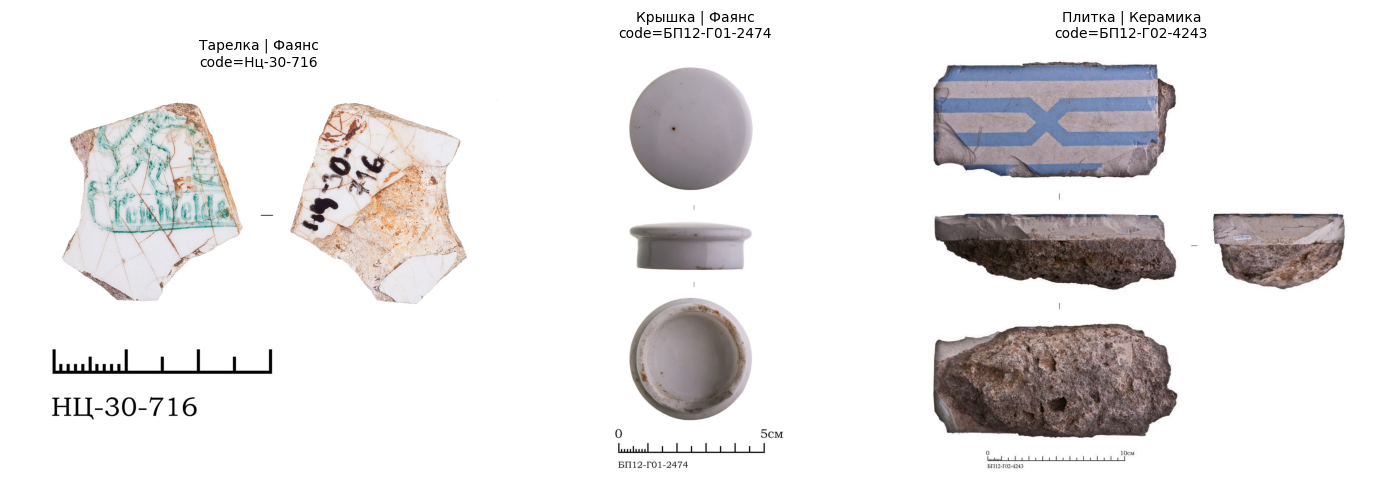

code     : Нц-30-716
name     : Тарелка
material : Фаянс
fragm    : Фрагмент
desc     : Тарелки фаянсовой с клеймом донца фр-т
file     : dataset\Нц-30-716_orig.jpg
------------------------------------------------------------
code     : БП12-Г01-2474
name     : Крышка
material : Фаянс
fragm    : Фрагмент
desc     : Сосуда фаянсового крышка фрагментированная
file     : dataset\БП12-Г01-2474_orig.jpg
------------------------------------------------------------
code     : БП12-Г02-4243
name     : Плитка
material : Керамика
fragm    : Фрагмент
desc     : Плитка напольная керамическая метлахская с голубой росписью и следами раствора фрагментированная
file     : dataset\БП12-Г02-4243_orig.jpg
------------------------------------------------------------


In [9]:
import matplotlib.pyplot as plt

sample = df_long.sample(3, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (_, r) in zip(axes, sample.iterrows()):
    img = Image.open(ROOT / r["image_file"])
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"{r['name']} | {r['material']}\ncode={r['code']}", fontsize=10)
plt.tight_layout(); plt.show()

for _, r in sample.iterrows():
    print(f"code     : {r['code']}")
    print(f"name     : {r['name']}")
    print(f"material : {r['material']}")
    print(f"fragm    : {r['fragm']}")
    print(f"desc     : {r['description']}")
    print(f"file     : {r['image_file']}")
    print("-" * 60)

In [10]:
INTERIM = Path("../data/interim")
INTERIM.mkdir(parents=True, exist_ok=True)
out_path = INTERIM / "items_with_images.csv"
df_long.to_csv(out_path, index=False)
print(f"Saved: {out_path}  ({len(df_long)} rows)")

Saved: ..\data\interim\items_with_images.csv  (1389 rows)
